Iniciamos importando las librerías requeridas para el desarrollodo del caso

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Adicionalmente, para este caso necesitaremos instalar la librería statsmodels, para eso debemos abrir el Anaconda Prompt, activar el ambiente del curso, y ejecutar el comando `conda install statsmodels`

# Analizando el Comportamiento Histórico de la Tasa Representativa del Mercado

En este caso se trabajará con dos series de tiempo, la serie de tiempo del histórico de la Tasa Representativa del Mercado (TRM) y la serie de tiempo del histórico del índice de precios al consumidor (IPC). Aprenderemos a determinar la tendencia y la estacionalidad de estas series y también a removerla para obtener sólo las variaciones principales. Al final, estableceremos una correlación entre las variaciones y seremos capaces de concluir sobre la influencia de la TRM sobre la inflación.

## Resultado previsto de aprendizaje
Al terminar este caso, el estudiante debe estar en la capacidad de importar datos con Pandas, de agruparlos y promediarlos usando las funciones `groupby` y `rolling`, y de visualizarlos con la librería Matplotlib. También debe estar en capacidad de establecer si una serie de tiempo es estacionaria y de remover tendencias usando promedios móviles.

---

## Contexto del Problema

A usted se le entregarán dos bases de datos con el histórico de la TRM y el histórico de la inflación anual. Su objetivo es transformar estas dos series de tiempo en series de tiempo estacionarias y establecer si existe una correlación entre estas dos variables muy importantes en economìa.

### Cargando los datos
Iniciamos cargando los datos con la información del valor histórico de la Tasa Representatitva del Mercado (TRM) y de la inflación usando los datos obtenidos directamente desde la página del Banco de la República

In [40]:
TRM = pd.read_csv('data/Tasa_de_Cambio_Representativa_del__Mercado_-Historico.csv')
IPC = pd.read_excel('data/IPC_Serie_variaciones.xlsx', skipfooter=3).drop(index=0)

Noten que hemos incluido dos argumentos adicionales a esta función para especificar que debemos ignorar algunas filas al principio del archivo (header), y también algunas filas al final (footer). Veamos como lucen las primeras líneas de nuestros DataFrames

In [41]:
TRM.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,4149.24,COP,02/04/2025,02/04/2025
1,4191.79,COP,01/04/2025,01/04/2025
2,4192.57,COP,29/03/2025,31/03/2025
3,4152.59,COP,28/03/2025,28/03/2025
4,4131.42,COP,27/03/2025,27/03/2025


In [42]:
IPC.tail()

,Fecha,Índice de Precios al Consumidor(Dato fin de mes),Índice de Precios al Consumidor(Variación porcentual mensual),Índice de Precios al Consumidor(Variación porcentual anual),Índice de Precios al Consumidor(Variación porcentual año corrido)
844,31/10/2024,"143,83","-0,13","5,41","4,44"
845,30/11/2024,"144,22","0,27","5,20","4,72"
846,31/12/2024,"144,88","0,46","5,20","5,20"
847,31/01/2025,"146,24","0,94","5,22","0,94"
848,28/02/2025,"147,90","1,14","5,28","2,08"


Veamos los formatos de las columnas:

In [43]:
TRM.dtypes

VALOR            float64
UNIDAD               str
VIGENCIADESDE        str
VIGENCIAHASTA        str
dtype: object

El tipo de variable `object` nos indica que las fechas no han sido procesadas con el tipo `datetime64`, que es un tipo de variable nuevo definido por Numpy para manejar formatos de fecha-hora y Pandas lo utiliza cuando detecta que una columna es de tipo fecha-hora. Es siempre una buena práctica trabajar fechas y horas en este formato. Procedamos a fijar las fechas con este formato

In [44]:
TRM['VIGENCIADESDE'] = pd.to_datetime(TRM['VIGENCIADESDE'], format='%d/%m/%Y')
TRM['VIGENCIAHASTA'] = pd.to_datetime(TRM['VIGENCIAHASTA'], format='%d/%m/%Y')
TRM.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,4149.24,COP,2025-04-02,2025-04-02
1,4191.79,COP,2025-04-01,2025-04-01
2,4192.57,COP,2025-03-29,2025-03-31
3,4152.59,COP,2025-03-28,2025-03-28
4,4131.42,COP,2025-03-27,2025-03-27


In [45]:
TRM.dtypes

VALOR                   float64
UNIDAD                      str
VIGENCIADESDE    datetime64[us]
VIGENCIAHASTA    datetime64[us]
dtype: object

Normalmente la TRM se calcula al final del día y tiene vigencia sobre todo el día siguiente, sin embargo, en los fines de semana no se hace el cálculo y la vigencia se extiende sobre todo el fin de semana.

Veamos ahora qué ocurre con el IPC

In [46]:
IPC.dtypes

Fecha                                                                 str
Índice de Precios al Consumidor(Dato fin de mes)                      str
Índice de Precios al Consumidor(Variación porcentual  mensual)        str
Índice de Precios al Consumidor(Variación porcentual  anual)          str
Índice de Precios al Consumidor(Variación porcentual  año corrido)    str
dtype: object

Todas las columnas, tanto numéricas como de fecha se han procesado de manera incorrecta. Hagamos la correción:

In [47]:
IPC['Fecha'] = pd.to_datetime(IPC['Fecha'], format='%d/%m/%Y')

Ahora apliquemos una pequeña reducción de código para actualizar los índices

In [48]:
for col in IPC.columns[1:]:
    IPC[col] = pd.to_numeric(IPC[col].str.replace(',', '.'), errors='coerce') 

Veamos el resultado

In [49]:
IPC.head(20)

,Fecha,Índice de Precios al Consumidor(Dato fin de mes),Índice de Precios al Consumidor(Variación porcentual mensual),Índice de Precios al Consumidor(Variación porcentual anual),Índice de Precios al Consumidor(Variación porcentual año corrido)
1,1954-07-31,0.03,NaN,NaN,NaN
2,1954-08-31,0.03,-0.76,NaN,-0.76
3,1954-09-30,0.03,-1.37,NaN,-2.12
4,1954-10-31,0.03,0.34,NaN,-1.79
5,1954-11-30,0.03,0.27,NaN,-1.52
6,1954-12-31,0.03,0.54,NaN,-1.00
7,1955-01-31,0.03,-0.17,NaN,-0.17
8,1955-02-28,0.03,-0.07,NaN,-0.23
9,1955-03-31,0.03,0.40,NaN,0.17
10,1955-04-30,0.03,0.70,NaN,0.87


In [50]:
IPC.dtypes

Fecha                                                                 datetime64[us]
Índice de Precios al Consumidor(Dato fin de mes)                             float64
Índice de Precios al Consumidor(Variación porcentual  mensual)               float64
Índice de Precios al Consumidor(Variación porcentual  anual)                 float64
Índice de Precios al Consumidor(Variación porcentual  año corrido)           float64
dtype: object

Ahora que ya tenemos la información adecuadamente podemos proceder a hacer un análisis, pero antes, unifiquemos la periodicidad en ambas bases de datos.

### Pasando los datos de TRM a una periodicidad mensual

Lo primero que haremos para poder correlacionar las dos variables será modificar la periodicidad de los datos de TRM de diaria a mensual. Una posible estrategia sería tomar todos los valores de TRM del mismo mes y promediarlos. Sin embargo, esta no es la misma estrategia que sigue el IPC, ya que este se fija con el último valor del mes. De manera que seguiremos una estrategia similar, el valor representativo de la TRM será el que tiene validez en la última fecha del mes.

In [51]:
TRM.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA
0,4149.24,COP,2025-04-02,2025-04-02
1,4191.79,COP,2025-04-01,2025-04-01
2,4192.57,COP,2025-03-29,2025-03-31
3,4152.59,COP,2025-03-28,2025-03-28
4,4131.42,COP,2025-03-27,2025-03-27


Para poder agrupar los datos por mes, vamos a ahora a crear una nueva columna con la información correspondiente únicamente al mes. Esto es muy fácil usando la función `dt.toperiod()`, veamos:

In [52]:
TRM['mes'] = TRM['VIGENCIADESDE'].dt.to_period('M')

TRM.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA,mes
0,4149.24,COP,2025-04-02,2025-04-02,2025-04
1,4191.79,COP,2025-04-01,2025-04-01,2025-04
2,4192.57,COP,2025-03-29,2025-03-31,2025-03
3,4152.59,COP,2025-03-28,2025-03-28,2025-03
4,4131.42,COP,2025-03-27,2025-03-27,2025-03


El parámetro `'M'` le dice a la función que queremos la información solo del mes, para obtener información del año usamos `'Y'`, de la semana usamos `'W'`, o del trimestre usamos `'Q'`.

#### La función `groupby`

Como su nombre lo indica, la función `groupby` sirve para agrupar conjuntos de datos que tengan los mismos valores en alguna, o algunas columnas. Sin embargo, el agrupamiento por si solo no es una salida con la que podamos trabajar, es siempre necesario decirle a `gropuby` qué deseamos hacer con los datos, esto es la función de agrupamiento.<br>

La estructura general de la función `groupby` es la siguiente:

`nombre_dataframe.groupby(columna_a_agrupar).funcion_agrupación()`

La Figura siguiente muestra algunos ejemplos de su utilización:

![Picture title](fig/C3_1.png)

En nuestro DataFrame todos los objetos correspondientes al mismo mes tienen el mismo valor en la columna `mes`, entonces podemos usar la función `groupby`, y posteriormente la función `idxmax`, para obtener el índice con el mayor valor de la columna `VIGENCIADESDE`.


In [53]:
TRM.groupby('mes')['VIGENCIADESDE'].idxmax()

mes
1991-12    7985
1992-01    7963
1992-02    7942
1992-03    7922
1992-04    7902
           ... 
2024-12      60
2025-01      41
2025-02      22
2025-03       2
2025-04       0
Freq: M, Name: VIGENCIADESDE, Length: 401, dtype: int64

El resultado es que para cada mes obtenemos un valor que corresponde al índice de la fila con el mayor valor de `VIGENCIADESDE`, como esta columna tiene un formato de fecha, el mayor valor corresponde al último día del mes que aparece en la base de datos. El paso a seguir es entonces, usar estos índices para filtrar la base de datos. Veamos:

In [54]:
TRM_mes = TRM.loc[TRM.groupby('mes')['VIGENCIADESDE'].idxmax()]
TRM_mes.reset_index(drop=True, inplace=True)
TRM_mes.head(10)

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA,mes
0,632.37,COP,1991-12-31,1991-12-31,1991-12
1,644.27,COP,1992-01-31,1992-01-31,1992-01
2,636.54,COP,1992-02-29,1992-03-02,1992-02
3,641.59,COP,1992-03-31,1992-03-31,1992-03
4,653.83,COP,1992-04-30,1992-04-30,1992-04
5,664.37,COP,1992-05-30,1992-06-02,1992-05
6,697.57,COP,1992-06-27,1992-06-30,1992-06
7,705.14,COP,1992-07-31,1992-07-31,1992-07
8,691.68,COP,1992-08-29,1992-08-31,1992-08
9,702.81,COP,1992-09-30,1992-09-30,1992-09


En efecto, ahora nuestra base de datos sólo tiene un valor mensual que corresponde al valor de cierre de TRM cada mes.

### Generando nuestra primera gráfica

Gracias a la integración entre Pandas y Matplotlib es posible generar visualizaciones de forma muy rápida usando la función `plot` de Pandas. Esta función está definida para la clase DataFrame y por lo tanto la podemos llamar de la siguiente manera:

<Axes: xlabel='mes'>

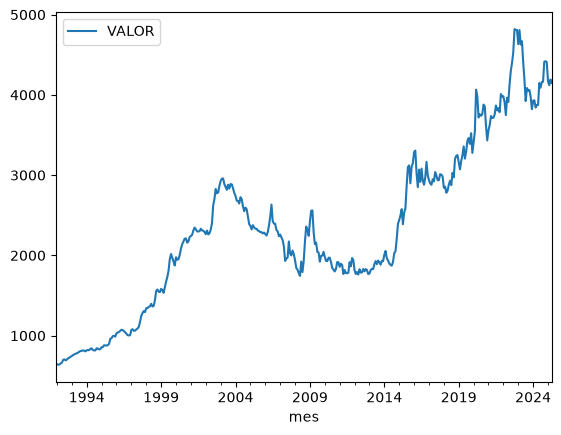

In [55]:
TRM_mes.plot('mes', 'VALOR')

El primer argumento de la función `plot` corresponde a la columna que queremos graficar en el eje *x* y el segundo argumento corresponde a la columna que queremos graficar en el eje *y*. 

Es posible modificar muchos parámetros de la gráfica incluyendo argumentos adicionales de configuración:

<Axes: title={'center': 'Histórico del valor de la TRM'}, xlabel='periodo mensual', ylabel='valor de cierre de la TRM en pesos'>

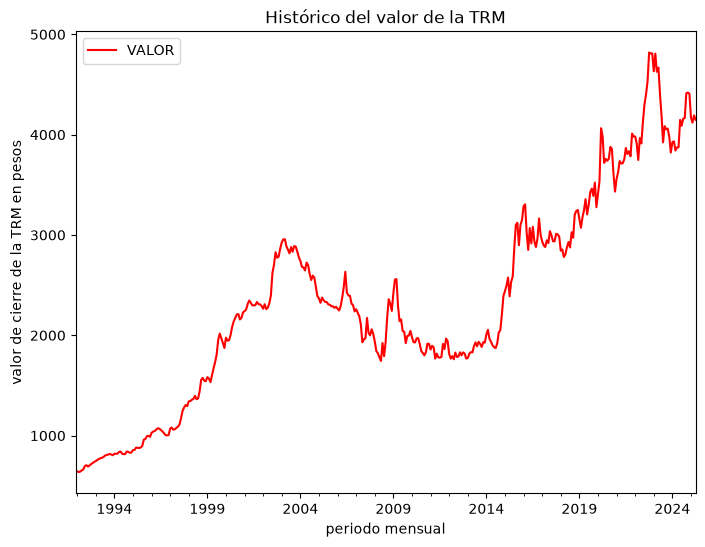

In [56]:
TRM_mes.plot('mes', 'VALOR', 
            figsize = (8,6), # cambia el tamaño de la gráfica
            xlabel = 'periodo mensual', # cambia el nombre del eje x
            ylabel = 'valor de cierre de la TRM en pesos', # cambia el nombre del eje y
            title = 'Histórico del valor de la TRM', # cambia el título de la gráfica
            color = 'red') # cambia el color de los datos

___
#### Ejercicio 1

Cree un nuevo DataFrame con los promedios anuales de la Tasa Representativa del Mercado. Posteriormente haga una gráfica con los datos obtenidos.

___

#### Ejercicio 2

Calcule para cada mes los valores máximos y mínimos de la Tasa Representativa del Mercado. Posteriormente réstelos para establecer la variación mensual de la TRM, y haga una gráfica de esta variación. ¿Con qué evento coincide la variación máxima observada?

___

Solución Ejercicio 1

<Axes: title={'center': 'Promedio anual de la TRM'}, xlabel='año', ylabel='TRM promedio anual en pesos'>

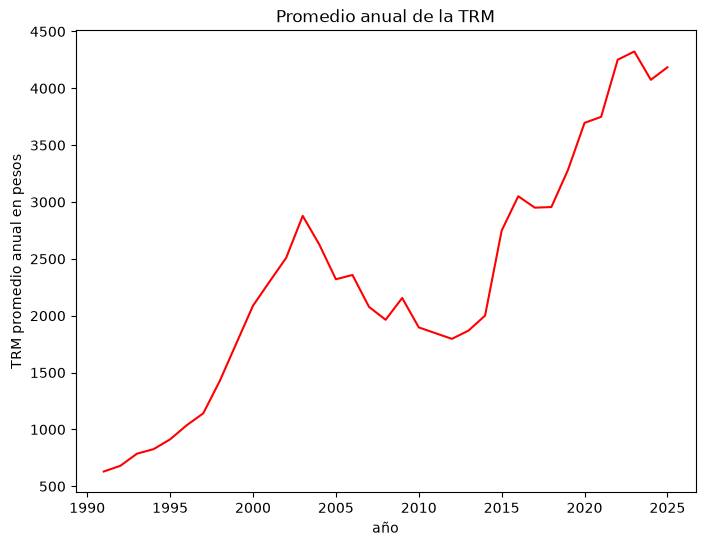

In [57]:
TRM['anio'] = TRM['VIGENCIADESDE'].dt.year #Crea una nueva columna con el año de la fecha
TRM_anio = TRM.groupby('anio')['VALOR'].mean() #

TRM_anio.plot(figsize=(8,6),
              xlabel='año',
              ylabel='TRM promedio anual en pesos',
              title='Promedio anual de la TRM',
              color='red')

Solución Ejercicio 2


Mes con mayor variación: 2020-03 -> $ 698.3499999999999


<Axes: title={'center': 'Variación del valor de la TRM'}, xlabel='periodo mensual', ylabel='variación de la TRM en pesos'>

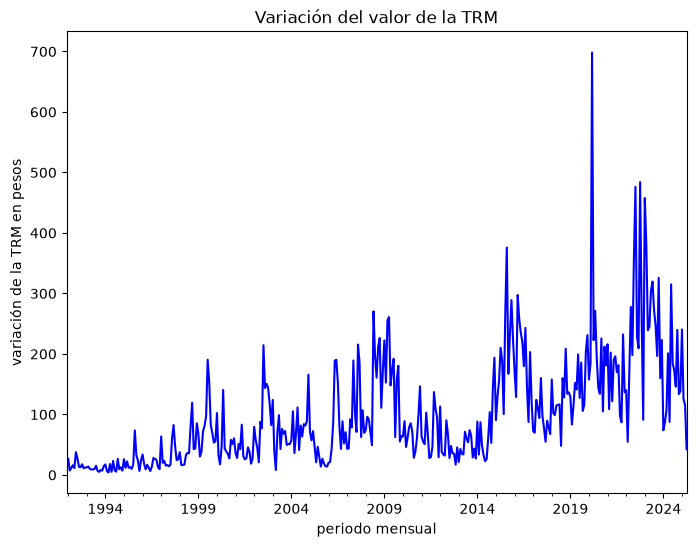

In [58]:
TRM.head()
TRM_Variación = (TRM.groupby('mes')['VALOR'].max() -TRM.groupby('mes')['VALOR'].min())
print('Mes con mayor variación:', TRM_Variación.idxmax(), '-> $',TRM_Variación.max())

TRM_Variación.plot(
            figsize = (8,6), # cambia el tamaño de la gráfica
            xlabel = 'periodo mensual', # cambia el nombre del eje x
            ylabel = 'variación de la TRM en pesos', # cambia el nombre del eje y
            title = 'Variación del valor de la TRM', # cambia el título de la gráfica
            color = 'blue') # cambia el color de los datos



### ¿Con qué evento coincide la variación máxima observada?

La variación máxima observada es en el año 2020 en el mes de marzo, esto coincide con el evento de pandemia COVID 19 con una variación de 698.34999, en ese entonces hubo panico simultáneo en los mercados globales, lo que disparo la demanda de dolares. 

### Análisis de Series de Tiempo

Las **series de tiempo** corresponden a datos que han sido recolectados y/o registrados en intervalos de tiempo **regulares** y cuyo comportamiento puede modelarse y predecirse a través de metologías estadísticas.

Con la finalidad de caracterizar series de tiempo, podemos utilizar de manera preliminar gráficas y medidas descriptivas. De acuerdo del comportamiento gráfico de la serie, podemos emplear algunos estadísticos para describirla:

* Cuando la serie fluctúa de forma constante alrededor de algún valor, se puede usar el **promedio de las observaciones** y su **desviación estándar**

- Si la serie tiene un comportamiento creciente o decreciente, podemos usar el **promedio de las tasas de variación** así como sus valores **máximo(s)** y/o **mínimo(s)** a nivel local o global. 



Podemos analizar la variación de una serie de tiempo teniendo en cuenta los elementos siguientes:

- **Tendencia:** indica el _movimiento_ de la serie a largo plazo.
- **Estacionalidad:** permite determinar efectos que se producen de forma periódica.
-  **Aleatoriedad:** caracteriza los elementos aleatorios en la serie.


#### Procesos Estocásticos y Deterministicos

Cuando hablamos de un **proceso estocástico** contamos con un conjunto de _variables aleatorias_ que podemos ordenar de acuedo a algún índice (que usualmente corresponde al tiempo):

$$\{x_t\}=\{...,x_1,x_2,x_3,x_4,...\}$$

Al trabajar con variables aleatorias, es necesario tener en cuenta que no podemos predecir su resultado para cada instante y, en lugar de ello, utilizamos distribuciones de probabilidad para entender su comportamiento.

Como contraparte de un proceso estocástico encontramos los **procesos determinísticos** en donde, sin importar cuántas veces realicemos un experimento, podremos predecir con total certeza el resultado que se obtendrá. Muchas veces sin embargo, cuando no conocemos todas las variables involucradas, podemos abordar un proceso determinístico como uno estocástico.

### Estacionariedad

El proceso estocástico que produce una serie de tiempo puede asociarse con una **distribución de probabilidad** y, cuando ésta no cambia en el tiempo, nos permite hacer inferencia y predecir el comportamiento de la serie con mayor seguridad. Esta característica se conoce como **estacionariedad**.

En resumen, una serie de tiempo es estacionaria si su media y su varianza permanecen constantes en el tiempo y si la serie no tiene una tendencia.

<span style="color:red">**NOTA:** Estacionalidad $\neq$ Estacionariedad</span>.


Claramente, la serie de tiempo de la TRM es no estacionaria ya que tiene una tendencia clara que cambia a lo largo del tiempo. Es difícil identificar para esta serie de tiempo una estacionalidad, ya que no hay patrones repetitivos claros. También es claro que esta serie de tiempo está afectada por fenómenos aleatorios, y de ahí que tenga muchas variaciones de poca frecuencia.

Sin embargo, hay situaciones en las que determinar la estacionariedad de una serie de tiempo no es tan evidente, y por eso se han desarrollado métodos estadísticos que nos pueden dar una estimación de con cuánta seguridad podemos hablar de una serie de tiempo estacionaria.

### Prueba Dickey-Fuller
La prueba Dickey-Fuller es una prueba estadística que nos permite probar la hipótesis nula de que la serie de tiempo es no-estacionaria. Como en todos los procesos de pruebas de hipótesis, el resultado de la prueba será un p-valor que deberemos interpretar de acuerdo con el nivel de significancia que queremos obtener. En general, podemos rechazar que la hipótesis nula, y aceptar entonces que la serie es estacionaria, con un nivel de confianza $1-\alpha$ si el p-valor satisface:<br>
$$p<\alpha$$

Apliquemos la prueba sobre nuestra serie de tiempo de valores de la TRM, para esto usaremos el paquete Statsmodels que como su nombre lo indica contiene muchas aplicaciones en estadística. La información específica de la función utilizada para hacer la prueba Dickey-Fuller puede ser encontrada en la documentación oficial:

https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html 

In [59]:
# Prueba de Dickey - Fuller para Estacionariedad
from statsmodels.tsa.stattools import adfuller

print('Prueba de Hipótesis Dickey-Fuller:')
dftest = adfuller(TRM_mes['VALOR'])
pvalor = dftest[1]  # el segundo elemento de la salida del test es el p-valor
print('p-valor: ', dftest[1])

significancia = 0.95
alpha = 1- significancia
print('Se puede rechazar la hipótesis nula: ', pvalor<alpha)

Prueba de Hipótesis Dickey-Fuller:
p-valor:  0.8251307364013145
Se puede rechazar la hipótesis nula:  False


No podemos rechazar en este caso la hipótesis nula, eso quiere decir que de acuerdo con la prueba la serie de tiempo es no-estacionaria, como esperábamos

### Obteniendo la tendencia de los datos

Una de las técnicas más utilizadas para eliminar la componente aleatoria de una serie de tiempo es hacer un promedio móvil, esto es, reemplazar cada dato por el promedio de los datos adyacentes tomado a lo largo de una ventana de tiempo que sea mayor a la frecuencia de las componentes aleatorias.

Los promedios móviles se pueden calcular fácilmente con Pandas usando la función `rolling`. En este caso usaremos un promedio móvil centrado usando una ventana de 1 año

In [60]:
# calculando el promedio móvil
TRM_mes['TRM_tendencia'] = TRM_mes['VALOR'].rolling(window=12, center=True).mean()

Grafiquemos ahora la tendencia y los valores originales al tiempo

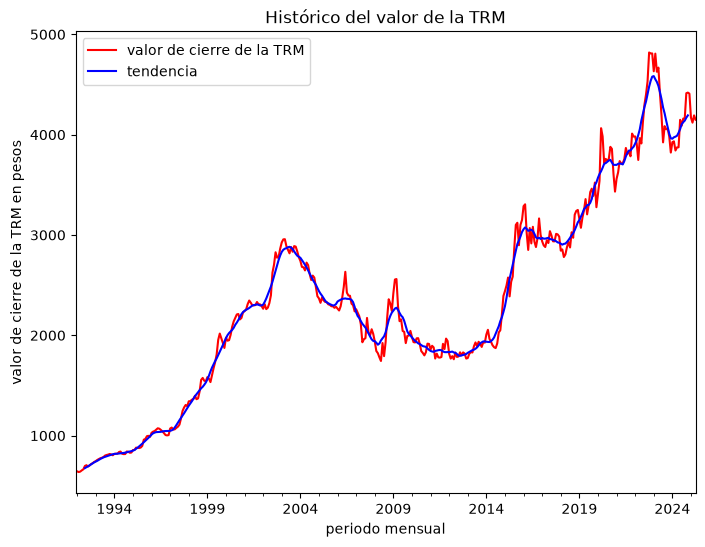

In [61]:
fig, ax = plt.subplots(figsize=(8,6))
TRM_mes.plot('mes', 'VALOR', ax=ax, color='red')
TRM_mes.plot('mes', 'TRM_tendencia', ax=ax, color='blue')
ax.set_xlabel('periodo mensual')
ax.set_ylabel('valor de cierre de la TRM en pesos')
ax.set_title('Histórico del valor de la TRM')
ax.legend(['valor de cierre de la TRM', 'tendencia'])


### Estacionalidad, revisando si hay componentes repetitivos

La estacionalidad en una serie de tiempo es la ocurrencia de patrones repetidamente con una frecuencia fija. Para evaluarla es necesario remover la tendencia de la serie de tiempo y hacer promedios sobre cada uno de los periodos, en este caso, los meses.

#### Modelo Aditivo de una Serie de Tiempo
Un modelo aditivo de una serie de tiempo se utiliza cuando se asume que los componentes de la serie interactúan de forma aditiva, es decir, las variaciones no se asumen proporcionales al valor de la variable. En este caso, se modela la serie de tiempo como la suma de sus componentes: tendencia, estacionalidad y residuo (o componente aleatorio).

El modelo aditivo se expresa matemáticamente como:

$$Y(t)=T(t)+S(t)+R(t) $$

donde:

- $Y(t)$ : Es el valor observado de la serie de tiempo en el tiempo  t .
- $T(t)$ : Es la tendencia de la serie de tiempo en el tiempo  t . Representa la dirección general de la serie a lo largo del tiempo (por ejemplo, una tendencia creciente o decreciente).
- $S(t)$ : Es el componente estacional en el tiempo  t . Refleja los patrones que se repiten en intervalos regulares (por ejemplo, patrones mensuales o estacionales).
- $R(t)$ : Es el componente aleatorio o residuo en el tiempo  t . Captura las variaciones aleatorias que no pueden explicarse por la tendencia o la estacionalidad.

##### Características del Modelo Aditivo

1. **Interacción Lineal**: En el modelo aditivo, las fluctuaciones en la serie de tiempo se consideran independientes de la magnitud de la serie. Es decir, los efectos de la estacionalidad y el residuo no dependen de la tendencia.
2. **Apropiado para Variabilidad Constante**: Se utiliza cuando se observa que la variabilidad en la serie de tiempo se mantiene constante, independientemente de los niveles de la serie. Por ejemplo, en temperaturas, donde los cambios estacionales son relativamente constantes.

##### Proceso de Descomposición Aditiva

Para descomponer una serie de tiempo utilizando el modelo aditivo, el procedimiento típico consiste en:

1. **Identificar la tendencia** \( T(t) \): Esto se hace mediante técnicas de suavizado, como el promedio móvil centrado.
2. **Restar la tendencia de la serie** para obtener la estacionalidad y el residuo combinados \( Y(t) - T(t) \).
3. **Calcular la estacionalidad** \( S(t) \): A menudo, se calcula tomando el promedio de los valores estacionales a lo largo de ciclos repetidos (por ejemplo, meses o trimestres).
4. **Obtener el residuo** \( R(t) \): Restando la estacionalidad al resultado anterior.

En resumen, el modelo aditivo se adapta bien cuando los efectos estacionales y aleatorios no dependen de la magnitud de la tendencia de la serie de tiempo.

#### Modelo Multiplicativo de una Serie de Tiempo

Un **modelo multiplicativo** de una serie de tiempo se utiliza cuando se asume que los componentes de la serie interactúan de manera proporcional. En este caso, se modela la serie de tiempo como el producto de sus componentes: tendencia, estacionalidad y residuo (o componente aleatorio).

El modelo multiplicativo se expresa matemáticamente como:

$$
Y(t) = T(t) \times S(t) \times R(t)
$$



donde:

- $Y(t) $: Es el valor observado de la serie de tiempo en el tiempo $ t $.
- $ T(t) $: Es la **tendencia** de la serie de tiempo en el tiempo $ t $. Representa la dirección general de la serie a lo largo del tiempo (por ejemplo, una tendencia creciente o decreciente).
- $ S(t) $: Es el **componente estacional** en el tiempo $ t $. Refleja los patrones que se repiten en intervalos regulares (por ejemplo, patrones mensuales o estacionales).
- $ R(t) $: Es el **componente aleatorio** o **residuo** en el tiempo $ t $. Captura las variaciones aleatorias que no pueden explicarse por la tendencia o la estacionalidad.

##### Características del Modelo Multiplicativo

1. **Interacción Proporcional**: En el modelo multiplicativo, las fluctuaciones en la serie de tiempo dependen proporcionalmente de la tendencia. Es decir, cuando la tendencia aumenta o disminuye, los efectos de la estacionalidad y el residuo se amplifican o reducen proporcionalmente.
2. **Apropiado para Variabilidad Proporcional**: Se utiliza cuando se observa que la variabilidad en la serie de tiempo cambia en proporción con la magnitud de la serie. Por ejemplo, en ventas de productos, donde los picos y valles aumentan proporcionalmente con las ventas totales.

##### Proceso de Descomposición Multiplicativa

Para descomponer una serie de tiempo utilizando el modelo multiplicativo, el procedimiento típico consiste en:

1. **Identificar la tendencia** $ T(t) $: Esto se hace mediante técnicas de suavizado, como el promedio móvil centrado.
2. **Dividir la serie por la tendencia** para obtener la estacionalidad y el residuo combinados $ \frac{Y(t)}{T(t)} $.
3. **Calcular la estacionalidad** $ S(t) $: A menudo, se calcula tomando el promedio de los valores estacionales a lo largo de ciclos repetidos (por ejemplo, meses o trimestres).
4. **Obtener el residuo** $ R(t) $: Dividiendo el valor observado por el producto de la tendencia y la estacionalidad.

En resumen, el modelo multiplicativo se adapta bien cuando los efectos estacionales y aleatorios varían en proporción a la tendencia de la serie de tiempo.

En nuestro caso, es de esperar que las variaciones en la TRM sean más grandes cuando la TRM es también mayor, por lo que tiene más sentido un modelo multiplicativo. Usemos este modelo entonces para remover la tendencia, el resultado será una curva que contiene las variaciones de la TRM en el mes con respecto a la tendencia

<Axes: xlabel='periodo mensual', ylabel='variación de la TRM'>

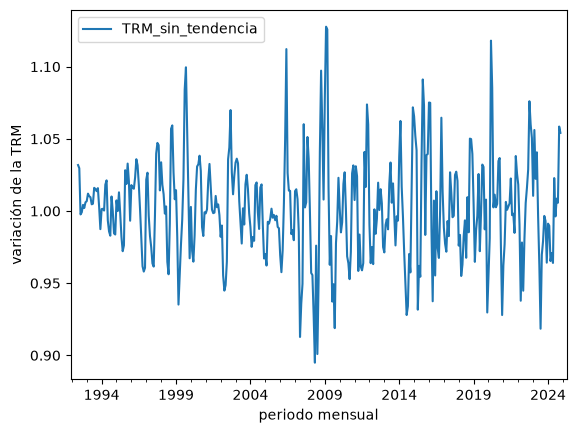

In [62]:
# definiendo el comportamiento sin tendencia
TRM_mes['TRM_sin_tendencia'] = TRM_mes['VALOR']/TRM_mes['TRM_tendencia']
# graficando las variaciones de la TRM sin tendencia
TRM_mes.plot('mes', 'TRM_sin_tendencia', xlabel='periodo mensual',ylabel='variación de la TRM')

El siguiente paso es determinar si existe algún patrón repetitivo en estas variaciones, para eso lo que haremos será agrupar los datos para obtener el promedio de estas variaciones sobre cada uno de los meses. Si en Enero, por ejemplo, hay una variación positiva repetitivamente, entonces este promedio tendrá un valor positivo claro. Si, por otro lado, las variaciones son aleatorias, a veces positivas o a veces negativas, el promedio tenderá a ser muy pequeño.

Para hacer este cálculo de nuevo usaremos la función `groupby`, esta vez agruparemos usando una columna que no existe en el dataset y que corresponde sólo al mes del año que estamos estudiando, veamos:

In [63]:
TRM_mes.groupby(TRM_mes['mes'].dt.month)['TRM_sin_tendencia'].mean()

mes
1     1.006123
2     1.004098
3     0.999647
4     0.989999
5     0.989899
6     0.993190
7     0.990041
8     1.003910
9     1.011928
10    1.013210
11    1.016864
12    1.002672
Name: TRM_sin_tendencia, dtype: float64

Tal vez esta información es más fácil de ver gráficamente:

<Axes: xlabel='mes'>

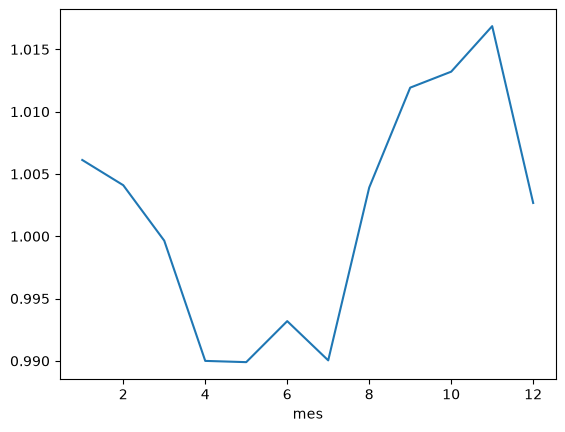

In [64]:
TRM_mes.groupby(TRM_mes['mes'].dt.month)['TRM_sin_tendencia'].mean().plot()

Lo que nos sugiere este análisis es que la estacionalidad es pequeña. La componente estacional sugiere que que históricamente, las mayores variaciones de la TRM se dan en Octubre y Noviembre (aunque son en promedio de apenas el 1.5%) y las variaciones más pequeñas se dan entre Abril y Julio (con un 1% negativo).

Agreguemos una nueva columna a nuestra base de datos con la componente estacional. Sin embargo, como vemos arriba, la función `groupby` normalmente nos produce una base de datos reducida a los valores únicos de la columna de agrupación. Podemos hacer que `groupby` mantenga el número de filas usando la función `transform`. Veamos:

In [67]:
TRM_mes.groupby(TRM_mes['mes'].dt.month)['TRM_sin_tendencia'].transform('mean')

0      1.002672
1      1.006123
2      1.004098
3      0.999647
4      0.989999
         ...   
396    1.002672
397    1.006123
398    1.004098
399    0.999647
400    0.989999
Name: TRM_sin_tendencia, Length: 401, dtype: float64

Como se observa, usando la opción `tranform` se puede agregar la media de cada mes a cada fila del dataframe.

In [68]:
TRM_mes['TRM_estacional'] = TRM_mes.groupby(TRM_mes['mes'].dt.month)['TRM_sin_tendencia'].transform('mean')

Veamos ahora gráficamente el resultado

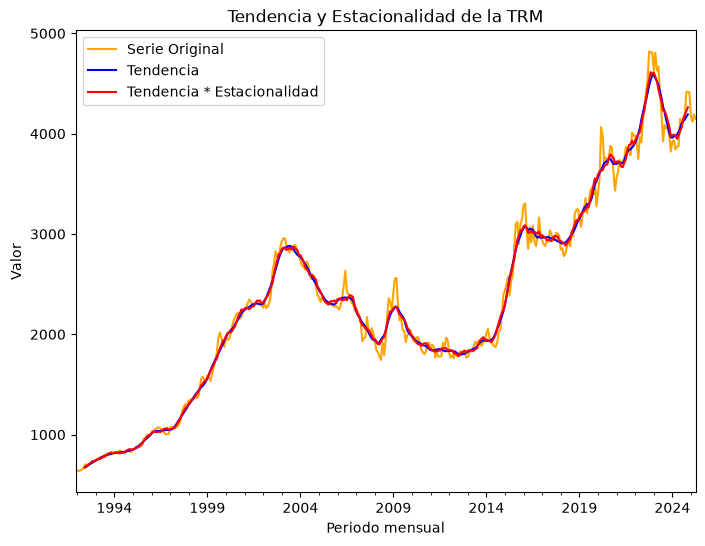

In [69]:
# Crear una nueva columna con la suma de tendencia y estacionalidad
TRM_mes['TRM_tendencia_estacional'] = TRM_mes['TRM_tendencia'] * TRM_mes['TRM_estacional']

# Graficar
fig, ax = plt.subplots(figsize=(8, 6))
TRM_mes.plot('mes', 'VALOR', ax=ax, color='orange', label='Serie Original')
TRM_mes.plot('mes', 'TRM_tendencia', ax=ax, color='blue', label='Tendencia')
TRM_mes.plot('mes', 'TRM_tendencia_estacional', ax=ax, color='red', label='Tendencia * Estacionalidad')


ax.set_xlabel('Periodo mensual')
ax.set_ylabel('Valor')
ax.set_title('Tendencia y Estacionalidad de la TRM')
ax.legend()

Como se observa, en efecto en este caso, las variaciones estacionales son muy pequeñas y realmente no reproducen las variaciones observadas en la TRM. Esto quiere decir que las variaciones en la TRM tienen un origen diferente. Finalmente podemos extraer el residuo de la serie de tiempo, que es el resultado de remover la tendencia y las componentes estacionales. Recordemos que estamos usando un modelo multiplicativo

<Axes: xlabel='periodo mensual', ylabel='residuo'>

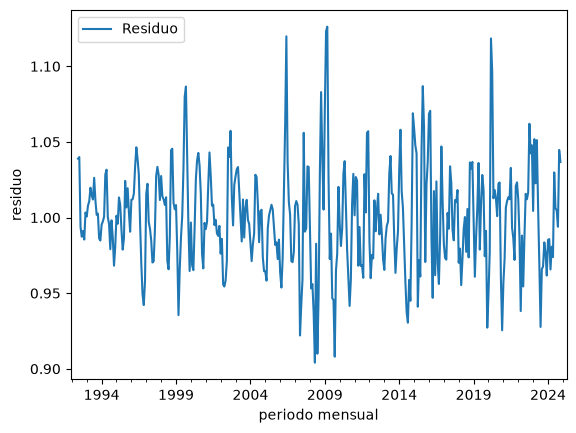

In [70]:
TRM_mes['Residuo'] = TRM_mes['VALOR'] / TRM_mes['TRM_tendencia_estacional']

TRM_mes.plot('mes', 'Residuo', xlabel='periodo mensual', ylabel='residuo')

Esta es entonces la serie de variaciones no explicadas ni con la tendencia, ni con una componente estacional. Típicamente esta serie de variaciones debe ser una serie estacionaria. Veamos

In [71]:
print('Prueba de Hipótesis Dickey-Fuller:')
dftest = adfuller(TRM_mes['Residuo'].dropna()) # debemos eliminar los NaN
pvalor = dftest[1]  # el segundo elemento de la salida del test es el p-valor
print('p-valor: ', dftest[1])

significancia = 0.95
alpha = 1- significancia
print('Se puede rechazar la hipótesis nula: ', pvalor<alpha)

Prueba de Hipótesis Dickey-Fuller:
p-valor:  3.1236880465350163e-16
Se puede rechazar la hipótesis nula:  True


Se puede entonces rechazar la hipótesis nula de que la serie es no estacionaria, podemos entonces concluir que es estacionaria.

#### Ejercicio 3
Calcule el residuo de la serie de tiempo, pero esta vez use un Modelo Aditivo. ¿Qué problema observa en la gráfica de serie de los residuos? ¿Existe alguna tendencia en la serie o en las variaciones de la serie?

Solución Ejercicio 3

<Axes: title={'center': 'Residuo de la TRM - Modelo Aditivo'}, xlabel='periodo mensual', ylabel='residuo (modelo aditivo)'>

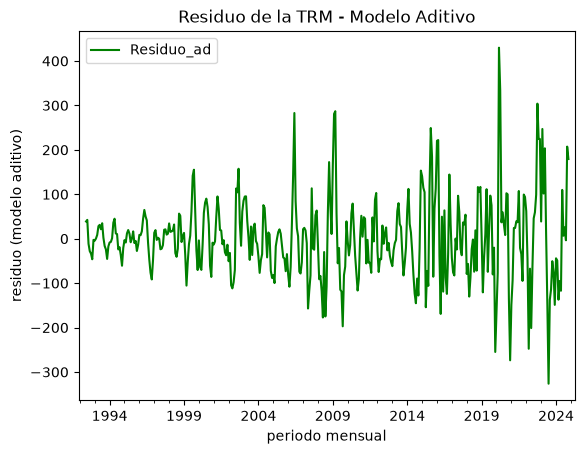

In [72]:
# Modelo aditivo: Y(t) = T(t) + S(t) + R(t)
# Reutilizamos la misma tendencia (promedio móvil de 12 meses) ya calculada antes

# 1. Removemos la tendencia restando (en vez de dividir, como en el modelo multiplicativo)
TRM_mes['TRM_sin_tendencia_ad'] = TRM_mes['VALOR'] - TRM_mes['TRM_tendencia']

# 2. Calculamos la componente estacional como el promedio de esas variaciones para cada mes del año
TRM_mes['TRM_estacional_ad'] = TRM_mes.groupby(TRM_mes['mes'].dt.month)['TRM_sin_tendencia_ad'].transform('mean')

# 3. Sumamos tendencia + estacionalidad
TRM_mes['TRM_tendencia_estacional_ad'] = TRM_mes['TRM_tendencia'] + TRM_mes['TRM_estacional_ad']

# 4. El residuo es lo que queda al restar tendencia y estacionalidad del valor original
TRM_mes['Residuo_ad'] = TRM_mes['VALOR'] - TRM_mes['TRM_tendencia_estacional_ad']

TRM_mes.plot('mes', 'Residuo_ad', xlabel='periodo mensual', ylabel='residuo (modelo aditivo)',
             title='Residuo de la TRM - Modelo Aditivo', color='green')

In [73]:
# Comprobamos si la dispersión del residuo es constante en el tiempo (requisito de estacionariedad)
residuo = TRM_mes['Residuo_ad'].dropna()
mitad = len(residuo) // 2

print('Media del residuo (debería ser ~0):', residuo.mean())
print('Desviación estándar - primera mitad (TRM baja):', residuo.iloc[:mitad].std())
print('Desviación estándar - segunda mitad (TRM alta):', residuo.iloc[mitad:].std())

Media del residuo (debería ser ~0): -1.6324263877975634e-14
Desviación estándar - primera mitad (TRM baja): 60.82798589002869
Desviación estándar - segunda mitad (TRM alta): 113.32655768642417


### ¿Qué problema observa en la gráfica de los residuos? ¿Hay tendencia?

La media del residuo sigue siendo ~0 a lo largo de toda la serie (no hay tendencia en el nivel), pero **la varianza no es constante**: la desviación estándar del residuo pasa de aproximadamente **61** en la primera mitad de la serie (años con TRM baja, ~600-2000) a aproximadamente **113** en la segunda mitad (TRM alta, >3000), casi el doble. Esto se ve en la gráfica como un "abanico": las oscilaciones del residuo son pequeñas al inicio y se hacen cada vez más grandes con el tiempo, aunque siempre centradas en cero.

Ese es el problema del modelo aditivo aquí: aunque no hay tendencia en la media, sí hay una tendencia clara en la **magnitud de las variaciones** (heterocedasticidad). Esto viola el requisito de varianza constante para que una serie sea estacionaria, y confirma por qué el modelo multiplicativo (usado antes) es más apropiado para la TRM: al dividir en vez de restar, sus residuos mantienen una dispersión mucho más estable en relación con el nivel de la serie.

In [74]:
# Comparación: ¿el ruido crece en pesos fijos, o en % constante del nivel de la TRM?
nivel_1 = TRM_mes['VALOR'].iloc[:mitad].mean()
nivel_2 = TRM_mes['VALOR'].iloc[mitad:].mean()

std_mult_1 = TRM_mes['TRM_sin_tendencia'].iloc[:mitad].std()
std_mult_2 = TRM_mes['TRM_sin_tendencia'].iloc[mitad:].std()

print(f'Nivel promedio TRM        -> primera mitad: {nivel_1:.0f}   | segunda mitad: {nivel_2:.0f}   | +{(nivel_2/nivel_1-1)*100:.0f}%')
print(f'Residuo aditivo (pesos)   -> primera mitad: {residuo.iloc[:mitad].std():.1f}    | segunda mitad: {residuo.iloc[mitad:].std():.1f}    | +{(residuo.iloc[mitad:].std()/residuo.iloc[:mitad].std()-1)*100:.0f}%')
print(f'Residuo multiplicativo (%) -> primera mitad: {std_mult_1*100:.2f}%  | segunda mitad: {std_mult_2*100:.2f}%  | +{(std_mult_2/std_mult_1-1)*100:.0f}%')

Nivel promedio TRM        -> primera mitad: 1734   | segunda mitad: 2907   | +68%
Residuo aditivo (pesos)   -> primera mitad: 60.8    | segunda mitad: 113.3    | +86%
Residuo multiplicativo (%) -> primera mitad: 2.87%  | segunda mitad: 4.08%  | +42%


### ¿Por qué el modelo multiplicativo es mejor para la TRM?

La pregunta clave es: **¿el "ruido" de la TRM se mantiene igual en pesos, o crece en la misma proporción que crece la propia TRM?** De eso depende si toca restar (aditivo) o dividir (multiplicativo) para remover la tendencia.

| | Primera mitad (TRM baja) | Segunda mitad (TRM alta) | Aumento |
|---|---|---|---|
| Nivel de la TRM | ~1736 | ~2934 | +69% |
| Residuo **aditivo** (en pesos) | std ≈ 61 | std ≈ 113 | **+86%** |
| Residuo **multiplicativo** (en % del nivel) | std ≈ 3.0% | std ≈ 3.8% | **+25%** |

**Intuición:** cuando la TRM valía ~700 pesos (años 90), un movimiento "normal" del mercado era de unos pocos pesos, pero esos pocos pesos ya representaban un 1-3% del valor total. Hoy, con la TRM en ~4000 pesos, ese mismo 1-3% equivale a decenas de pesos. Es decir: **la volatilidad de una tasa de cambio no es un monto fijo en pesos, es un porcentaje relativamente estable del nivel actual** — igual que pasa con acciones o cualquier precio de mercado, por eso en finanzas casi nunca se analizan movimientos en unidades absolutas sino en retornos porcentuales.

**Por qué falla el aditivo:** al restar la tendencia (`VALOR - TRM_tendencia`), el residuo queda en **pesos**. Como el "tamaño normal" del movimiento crece con el nivel de la TRM, ese residuo en pesos también crece con el tiempo (+86%), lo que se ve como el "abanico" en la gráfica. Eso es heterocedasticidad: varianza no constante, así que el residuo **no es realmente estacionario** aunque su media siga en cero.

**Por qué funciona el multiplicativo:** al dividir (`VALOR / TRM_tendencia`), el residuo queda expresado como una **razón/porcentaje** respecto al nivel de ese momento, normalizando automáticamente el tamaño del ruido por el nivel de la TRM en cada punto del tiempo. Por eso su dispersión crece mucho menos (+25% vs +86%) y se acerca bastante más a ser constante — justo lo que se necesita para que el residuo sea una serie estacionaria de verdad (y por eso la prueba de Dickey-Fuller sobre `Residuo` concluyó estacionariedad).

**En una frase:** el aditivo asume que el ruido es un monto fijo en pesos; el multiplicativo asume que es un porcentaje fijo del nivel actual. Para una tasa de cambio, la segunda suposición es la que se cumple en la práctica.

### Correlación con el IPC

Continuamos nuestro estudio para establecer si existe alguna influencia de la TRM sobre los aumentos de precio en el país. Para arrancar, de nuevo acudiremos al histórico de los datos de inflación que se encuentra en el Banco de la República.

In [75]:
IPC.columns

Index(['Fecha', 'Índice de Precios al Consumidor(Dato fin de mes)',
       'Índice de Precios al Consumidor(Variación porcentual  mensual)',
       'Índice de Precios al Consumidor(Variación porcentual  anual)',
       'Índice de Precios al Consumidor(Variación porcentual  año corrido)'],
      dtype='str')

Renombremos primero las columnas con las que vamos a trabajar

In [76]:
IPC.rename(columns = {'Índice de Precios al Consumidor(Dato fin de mes)': 'IPC'}, inplace = True)

Observemos la evaluación de la inflación acumulada anual a lo largo del tiempo:

<Axes: title={'center': 'Histórico de evolución del IPC'}, xlabel='periodo', ylabel='IPC'>

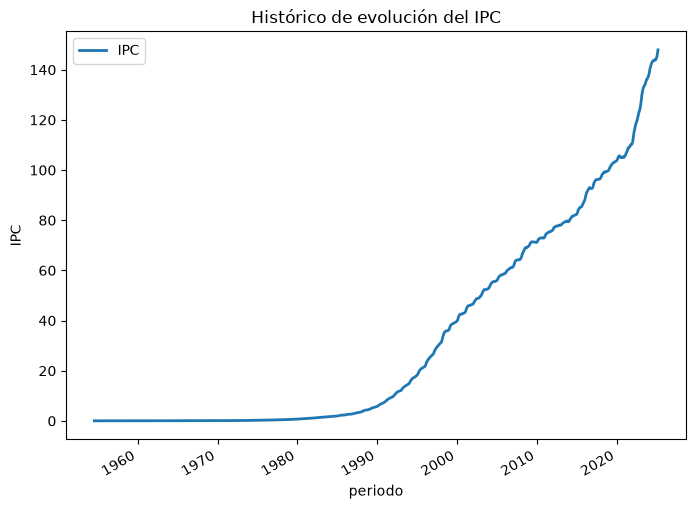

In [77]:
IPC.plot(x='Fecha', y='IPC', figsize = (8,6), # cambia el tamaño de la gráfica
            xlabel = 'periodo', # cambia el nombre del eje x
            ylabel = 'IPC', # cambia el nombre del eje y
            title = 'Histórico de evolución del IPC', # cambia el título de la gráfica
            linewidth = 2) # cambia el título de la gráfica

La gráfica tiene muy pocas variaciones antes de 1980, para nuestro análisis usaremos los datos posteriores a 1990 (que son los mismos de la serie de TRM)

In [78]:
IPC = IPC[IPC['Fecha'].dt.year>=1990]
IPC

,Fecha,IPC,Índice de Precios al Consumidor(Variación porcentual mensual),Índice de Precios al Consumidor(Variación porcentual anual),Índice de Precios al Consumidor(Variación porcentual año corrido)
427,1990-01-31,5.97,3.30,26.69,3.30
428,1990-02-28,6.19,3.66,27.12,7.09
429,1990-03-31,6.37,2.89,27.63,10.19
430,1990-04-30,6.55,2.81,27.98,13.29
431,1990-05-31,6.68,1.95,28.24,15.51
...,...,...,...,...,...
844,2024-10-31,143.83,-0.13,5.41,4.44
845,2024-11-30,144.22,0.27,5.20,4.72
846,2024-12-31,144.88,0.46,5.20,5.20
847,2025-01-31,146.24,0.94,5.22,0.94


#### Usando `statsmodels` para hacer el análisis de descomposición de series

Aunque ya sabemos cómo hacer la descomposición de una serie de tiempo adecuadamente, podemos ayudarnos de librerías que hacen el trabajo por nosotros. La librería

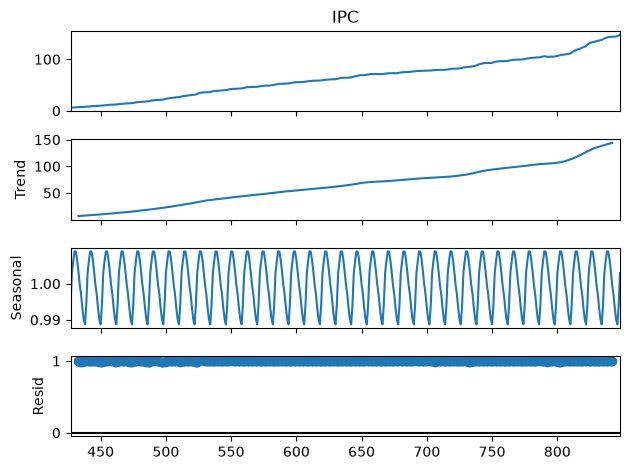

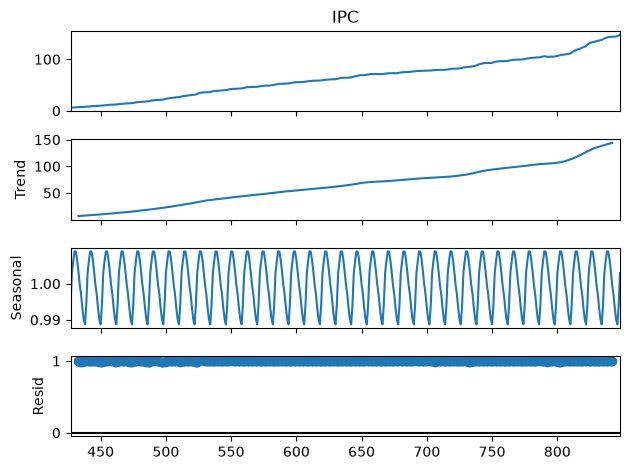

In [79]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the IPC time series
decomposition = seasonal_decompose(IPC['IPC'], model='multiplicative', period=12)

# Extract the components
ipc_trend = decomposition.trend
ipc_seasonal = decomposition.seasonal
ipc_residual = decomposition.resid

decomposition.plot()

Una vez que hemos descompuesto la señal, podemos integrar las componentes a la base de datos original:

In [80]:
IPC['IPC_tendencia'] = ipc_trend
IPC['IPC_estacional'] = ipc_seasonal
IPC['IPC_residuo'] = ipc_residual
IPC.head(10)

,Fecha,IPC,Índice de Precios al Consumidor(Variación porcentual mensual),Índice de Precios al Consumidor(Variación porcentual anual),Índice de Precios al Consumidor(Variación porcentual año corrido),IPC_tendencia,IPC_estacional,IPC_residuo
427,1990-01-31,5.97,3.30,26.69,3.30,NaN,0.994157,NaN
428,1990-02-28,6.19,3.66,27.12,7.09,NaN,1.002904,NaN
429,1990-03-31,6.37,2.89,27.63,10.19,NaN,1.006224,NaN
430,1990-04-30,6.55,2.81,27.98,13.29,NaN,1.008939,NaN
431,1990-05-31,6.68,1.95,28.24,15.51,NaN,1.008883,NaN
432,1990-06-30,6.81,1.95,28.97,17.77,NaN,1.006615,NaN
433,1990-07-31,6.90,1.35,28.72,19.36,6.919583,1.003352,0.993839
434,1990-08-31,7.01,1.58,28.98,21.26,7.080833,0.999719,0.990275
435,1990-09-30,7.18,2.37,30.24,24.14,7.245417,0.997048,0.993905
436,1990-10-31,7.31,1.92,30.65,26.54,7.413333,0.993255,0.992757


Analicemos más de cerca la  componente estacional

(np.float64(14610.0), np.float64(14974.0))

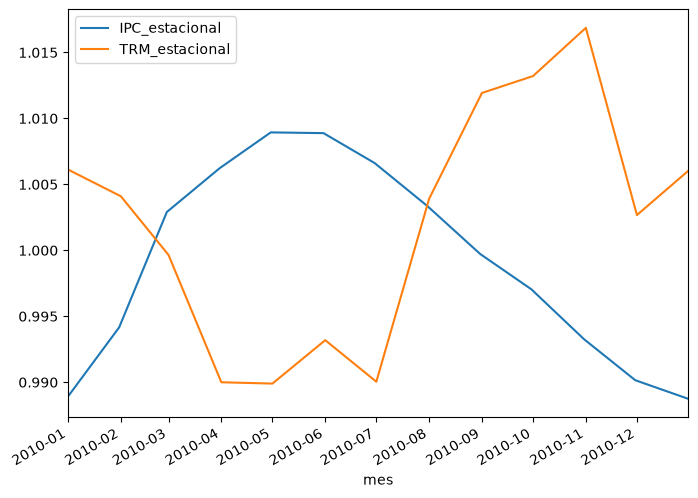

In [81]:
fig,ax = plt.subplots(figsize=(8, 6))
IPC.plot(x='Fecha', y='IPC_estacional', figsize = (8,6), ax = ax) # cambia el tamaño de la gráfica
TRM_mes.plot(x='mes', y='TRM_estacional', figsize = (8,6), ax = ax) # cambia el tamaño de la gráfica
ax.set_xlim(pd.Timestamp('2010-01-01'), pd.Timestamp('2010-12-31'))

Como se observa, en este caso las componentes estacionales son pequeñas, pero la curva muestra que consistentemente en los meses de mayo a junio tiende a haber variaciones positivas en los precios, mientras que en los meses de noviembre, diciembre y enero, las variaciones son negativas.

Veamos ahora el comportamiento del residuo en este caso

<Axes: xlabel='Fecha'>

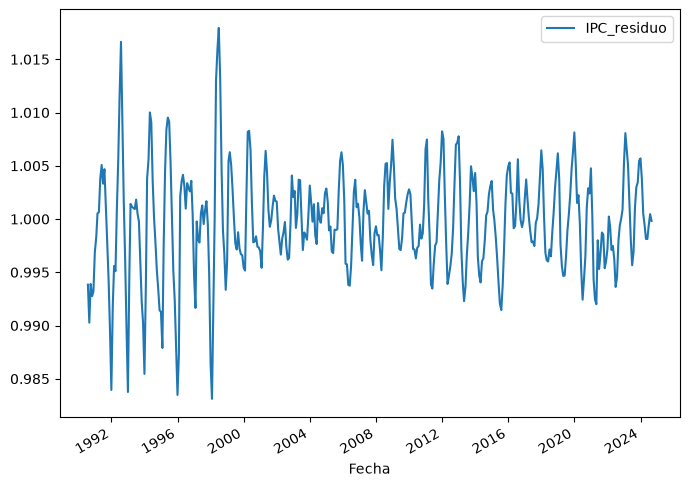

In [82]:
IPC.plot(x='Fecha', y='IPC_residuo', figsize = (8,6)) # cambia el tamaño de la gráfica

Como se observa, las variaciones más grandes se observan para los primeros años de la base de datos, sin embargo, esto se puede deber principalmente a variaciones numéricas. 

In [83]:
IPC.head()

,Fecha,IPC,Índice de Precios al Consumidor(Variación porcentual mensual),Índice de Precios al Consumidor(Variación porcentual anual),Índice de Precios al Consumidor(Variación porcentual año corrido),IPC_tendencia,IPC_estacional,IPC_residuo
427,1990-01-31,5.97,3.30,26.69,3.30,NaN,0.994157,NaN
428,1990-02-28,6.19,3.66,27.12,7.09,NaN,1.002904,NaN
429,1990-03-31,6.37,2.89,27.63,10.19,NaN,1.006224,NaN
430,1990-04-30,6.55,2.81,27.98,13.29,NaN,1.008939,NaN
431,1990-05-31,6.68,1.95,28.24,15.51,NaN,1.008883,NaN


#### La función `merge`

La función `merge` es muy útil cuando se trata de llevar a un DataFrame la información que se encuentra en otro DataFrame. En ambos DataFrames debe haber una columna común con respecto a la cual se hará la asignación. La Figura siguiente muestra la sintaxis general y el resultado esperado de usar la función `merge`:

![Picture title](fig/C3_3.png)

Para usar la función merge, primero definiremos una columna `mes` también en la serie de tiempo del IPC

In [84]:
IPC['mes'] = IPC['Fecha'].dt.to_period('M')

Ahora usamos la función `merge` para unir la información de las variaciones de la TRM, con las variaciones de la inflación.

In [85]:
TRM_mes = TRM_mes.merge(IPC[['mes','IPC_residuo', 'IPC_tendencia', 'IPC_estacional']], on = 'mes', how = 'left')

In [86]:
TRM_mes.head()

,VALOR,UNIDAD,VIGENCIADESDE,VIGENCIAHASTA,mes,TRM_tendencia,TRM_sin_tendencia,TRM_estacional,TRM_tendencia_estacional,Residuo,TRM_sin_tendencia_ad,TRM_estacional_ad,TRM_tendencia_estacional_ad,Residuo_ad,IPC_residuo,IPC_tendencia,IPC_estacional
0,632.37,COP,1991-12-31,1991-12-31,1991-12,NaN,NaN,1.002672,NaN,NaN,NaN,7.032005,NaN,NaN,0.983949,9.970417,0.988748
1,644.27,COP,1992-01-31,1992-01-31,1992-01,NaN,NaN,1.006123,NaN,NaN,NaN,9.422656,NaN,NaN,0.991800,10.182500,0.994157
2,636.54,COP,1992-02-29,1992-03-02,1992-02,NaN,NaN,1.004098,NaN,NaN,NaN,8.574453,NaN,NaN,0.995586,10.395833,1.002904
3,641.59,COP,1992-03-31,1992-03-31,1992-03,NaN,NaN,0.999647,NaN,NaN,NaN,-0.798750,NaN,NaN,0.995103,10.606250,1.006224
4,653.83,COP,1992-04-30,1992-04-30,1992-04,NaN,NaN,0.989999,NaN,NaN,NaN,-20.990937,NaN,NaN,1.000801,10.814583,1.008939


Grafiquemos ahora las dos series de tiempo en paralelo.

Text(0, 0.5, 'residuo en IPC')

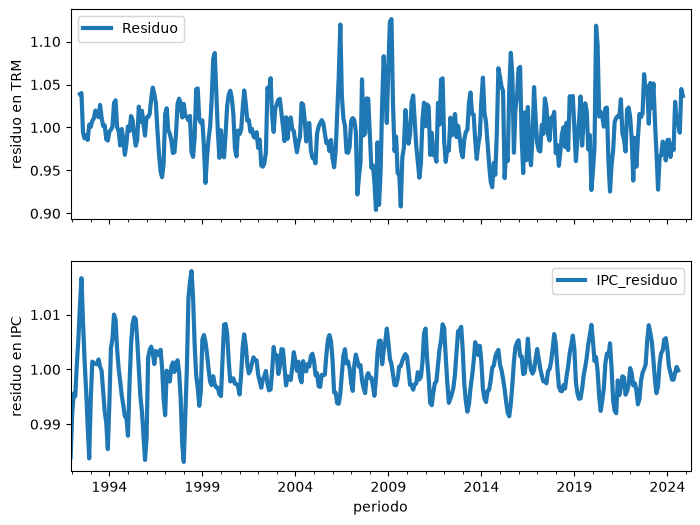

In [87]:
# definimos un elemento figura, y una lista de ejes
fig, axs = plt.subplots(2,1,figsize = (8,6), sharex = True)

# graficos en el eje 0
TRM_mes.plot('mes', 'Residuo', linestyle='-', linewidth = 3, ax = axs[0])
TRM_mes.plot('mes', 'IPC_residuo', linestyle='-', linewidth = 3, ax = axs[1])


# configuración eje 0
axs[0].set_ylabel('residuo en TRM') # fijamos el nombre del eje y

# configuración eje 1
axs[1].set_xlabel('periodo')  # fijamos el nombre del eje x
axs[1].set_ylabel('residuo en IPC')

#### Correlación de Pearson
Formalmente la Correlación de Pearon es una medida de la Covarianza entre dos series de datos. Esto quiere decir que es una medida de qué tanto se relacionan linealmente las dos series. En series de tiempo perfectamente correlacionados, la Correlación de Pearson es 1 o -1. En el primer caso el signo positivo implica que aumentos en una serie siempre están acompañados de aumentos en la segunda, en el segundo caso el signo negativo implica que aumentos en la primera serie siempre conllevan a disminuciones en la segunda. Si no existe ninguna correlación entre dos series, entonces la Correlación de Pearson es 0.

Podemos ahora calcular la correlación de Pearson existente entre las dos series de tiempo una desplazada con respecto a la otra, y veamos si existen algunos efectos de retraso

Inicialmente, hagamos el análisis únicamente con los residuos

In [88]:
from scipy.stats import pearsonr

# Initialize an empty list to store the results
results = []

# Loop through lags from -6 to 6
for lag in range(-6, 7):
    # Shift the 'Residuo' column by the current lag
    shifted_residuo = TRM_mes['Residuo'].shift(lag)
    original_residuo = TRM_mes['IPC_residuo']
    
    data = pd.concat([shifted_residuo, original_residuo], axis=1).dropna()
    
    
    # Calculate the correlation and p-value
    correlation, p_value = pearsonr(data.iloc[:, 0], data.iloc[:, 1])
    
    # Append the results to the list
    results.append({'lag': lag, 'correlation': correlation, 'p_value': p_value})

# Create a DataFrame from the results
correlation_df = pd.DataFrame(results)

# Display the DataFrame
correlation_df

,lag,correlation,p_value
0,-6,0.000493,0.992262
1,-5,0.027781,0.584395
2,-4,0.033379,0.511018
3,-3,0.012147,0.811016
4,-2,-0.031978,0.529462
5,-1,-0.044708,0.379813
6,0,0.008737,0.863962
7,1,0.054885,0.282095
8,2,0.050666,0.321424
9,3,0.012754,0.803267


Los resultados no nos permiten concluir que haya una relación directa entre las variaciones en la TRM y la variaciones de los precios al consumidor en Colombia.

___

#### Ejercicio 4
Calcule la correlación existente entre las columnas `TRM_estacional` y `IPC_estacional` en el DataFrame `TRM_mes`. ¿Se espera una correlación alta o baja?

___

In [90]:
# Respuesta directa al ejercicio: correlacion entre las dos componentes estacionales
correlacion_directa = TRM_mes['TRM_estacional'].corr(TRM_mes['IPC_estacional'])
print('Correlacion TRM_estacional vs IPC_estacional (mismo mes):', round(correlacion_directa, 4))

# Analisis adicional: correlacion a distintos desfases (lags) para ver el ciclo anual
from scipy.stats import pearsonr

results = []
for lag in range(-6, 7):
    shifted = TRM_mes['TRM_estacional'].shift(lag)
    original = TRM_mes['IPC_estacional']
    data = pd.concat([shifted, original], axis=1).dropna()
    correlation, p_value = pearsonr(data.iloc[:, 0], data.iloc[:, 1])
    results.append({'lag': lag, 'correlation': correlation, 'p_value': p_value})

correlation_df = pd.DataFrame(results)
correlation_df

Correlacion TRM_estacional vs IPC_estacional (mismo mes): -0.802


,lag,correlation,p_value
0,-6,0.921676,1.079863e-163
1,-5,0.771847,1.682799e-79
2,-4,0.443940,1.330883e-20
3,-3,-0.042140,4.017932e-01
4,-2,-0.465944,6.766770e-23
5,-1,-0.720143,5.251604e-65
6,0,-0.802042,6.865610e-91
7,1,-0.747336,2.646038e-72
8,2,-0.505561,3.794337e-27
9,3,-0.051723,3.045591e-01


Segun los resultados obtenidos, la correlacion directa entre `TRM_estacional` e `IPC_estacional` (mismo mes, lag = 0) es de aproximadamente **-0.80**: una correlacion **alta en magnitud pero negativa**. Esto significa que cuando la componente estacional de la TRM esta en su parte alta del ano, la del IPC tiende a estar en su parte baja; es decir, sus ciclos anuales estan **desfasados alrededor de medio ano**. Por eso, en la tabla de desfases, la correlacion cambia de signo cada ~6 meses y alcanza su maximo positivo (~+0.92) en los lags -6 y +6.

Hay que interpretar este valor con cuidado: las componentes estacionales son curvas que se repiten identicas cada 12 meses, y al correlacionar dos ciclos anuales suaves casi siempre se obtiene una magnitud alta (positiva o negativa segun como esten alineados sus picos). Por lo tanto, un valor alto aqui no prueba por si solo una relacion economica profunda entre la TRM y el IPC; en buena parte es consecuencia de que ambas son ciclos anuales simples. Esto es consistente con la conclusion del caso: la componente estacional, si bien es pequena, si presenta ciclos anuales relacionados.

## Conclusiones

Hemos aprendido a trabajar con DataFrames para agrupar los datos y sacar promedios, y también para juntar información procedente de DataFrames diferentes. Hemos aprendido cómo determinar la tendencia de una serie de tiempo usando promedios móviles y también a aislar las componentes estacionales y aleatorias removiendo la tendencia. También hemos aprendido sobre la prueba Dickey-Fuller para determinar estacionariedad y sobre la correlación de Pearson para establecer correlación entre series de tiempo.

Hemos aplicado una descomposición multiplicativa sobre las series de tiempo del IPC y de la TRM y hemos encontrado que no hay relación significativa entre sus residuos. Sin embargo, su componente estacional, si bien es pequeña, sí tiene ciclos anuales relacionados.

### Origen de los datos
* Valor histórico de la TRM <br>
https://www.banrep.gov.co/es/estadisticas/trm 
* Indice de Precios al Consumidor - IPC <br>
https://www.banrep.gov.co/es/estadisticas/indice-precios-consumidor-ipc